# Training 2D O(3) diffusion models

Training and basic diagnostics for score-based diffusion models of the two-dimensional O(3) model at $\beta=1.5$.

The first model is trained directly on $64\times64$ MCMC configurations.  A second model is trained on $16\times16$ configurations obtained by decimating the same training set.  The final sections compare bare diffusion-model samples with the MCMC correlation function and topological observables, without MCMC cleanup.


## Initialization


In [2]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import model

import mcmc_2d as mcmc
import rotation as rot
import sde
import sphere

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\t" + (f"{torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU"))

sphere.setDevice(device)


Using device: cuda	NVIDIA A100-SXM4-40GB


In [ ]:
# 100,000 MCMC configurations on a 64 x 64 lattice
cfgsTraining = torch.load("data/MCMC/cfgs_L64_beta1p5.pt")
cfgsTraining.shape


torch.Size([100000, 64, 64, 3])

In [3]:
beta = 1.5

# Precalculated correlation function of the training set
corrTraining = [1.,0.6017,0.4339,0.3402,0.2781,0.2328,0.1978,0.1698,0.1469,0.1279,0.1120,0.0985,0.0869,0.0770,0.0684,
    0.0609,0.0545,0.0488,0.0439,0.0396,0.0359,0.0326,0.0298,0.0274,0.0254,0.0236,0.0221,0.0210,0.0200,0.0193,0.0187,0.0184,0.0183]

# At nonzero diffusion time the l=1 spherical harmonic decays as exp(-2 tau),
# so the two-point function picks up exp(-4 tau).
u = 0.5
t = sde.tauFromU(u)
fact = torch.exp(-4.*t).item()
corrDiff = [1.]
for i in range(32):
    corrDiff.append(fact*corrTraining[i+1])


In [34]:
def score(x, t, scoreNet):
    u = sde.uFromTau(t)

    with torch.no_grad():
        omega = scoreNet(x, u)
        return torch.cross(omega, x, dim=-1)

def sampleSDE(trials, L, evals, scoreNet, uMid = 0.0, langevin = False, langEvals = 0, finalEvals = 0, ds = .01):
    cfgsOut = mcmc.randomSpins(trials, L, device=next(scoreNet.parameters()).device)
    tau = sde.tauFromU(torch.linspace(1., uMid, evals+1))

    for i in tqdm(range(len(tau)-1)):
        dt = tau[i]-tau[i+1]
        cfgsOut = sde.eulerMaruyamaStep(cfgsOut, tau[i], dt, lambda x, t : score(x, t, scoreNet))

    if(langevin):
        for i in tqdm(range(langEvals)):
            cfgsOut = sde.langevinStep(cfgsOut, sde.tauFromU(uMid).item(), ds, lambda x, t : score(x, t, scoreNet))

        tau = sde.tauFromU(torch.linspace(uMid, 0.0, finalEvals+1))
        for i in tqdm(range(len(tau)-1)):
            dt = tau[i]-tau[i+1]
            cfgsOut = sde.eulerMaruyamaStep(cfgsOut, tau[i], dt, lambda x, t : score(x, t, scoreNet))

    return cfgsOut


## Training the 64 x 64 model

The network is first initialized at the two endpoints of the diffusion: the exact O(3) score at $u=0$ and a vanishing score at $u=1$.  The main training then uses denoising score matching at random diffusion times, with a random global O(3) rotation applied to each batch.


In [ ]:
L = 64

uNet = model.UNet(dim = 2).to(device)

numParameters = sum(p.numel() for p in uNet.parameters())
print(f"Number of parameters = {numParameters}")


Number of parameters = 313171


### Endpoint pretraining


In [ ]:
lr = 1e-4
optimizer = torch.optim.Adam(uNet.parameters(), lr=lr, betas=(0.9, 0.999))

batch_size = 32
data_loader = DataLoader(cfgsTraining, batch_size=batch_size, shuffle=True)

n_epochs = 2

for i in range(n_epochs):

    lossTot = 0.0
    nDiag = 0

    for step, x0 in enumerate(tqdm(data_loader), start=1):

        x0 = x0.to(device)
        isInitialTime = random.choice([True, False])
        u = 0.0 if isInitialTime else 1.0

        # rotate batch of vectors by a random rotation
        mat = rot.rotFromQ(rot.randomQ(device=device))
        x0 = torch.einsum('ij,...j->...i', mat, x0)

        # network score
        omega = uNet(x0, u)
        prediction = torch.cross(omega, x0, dim=-1)

        if isInitialTime:
            target = mcmc.exactScore(x0, beta)
            loss = torch.sum((prediction-target)**2, dim=-1).mean()
        else:
            loss = torch.sum(prediction**2, dim=-1).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(uNet.parameters(), max_norm=1.0)
        optimizer.step()

        lossTot += loss.item()
        nDiag += 1

    print(f'avg loss: {lossTot/nDiag}')

torch.save(uNet.state_dict(), "data/Models/uNet2D_pretraining.pt")


### Main training loop

For the main DSM loss, $u$ is sampled uniformly and converted to the heat-kernel diffusion time $\tau(u)$.  The factor $\tau+\tau_I$ implements likelihood weighting, proportional to $d\tau/du$.  Two exponential moving averages were tracked during training, although the bare network checkpoint is used for the diagnostics below.


In [ ]:
# Main training used much larger batches than the endpoint pretraining.
batch_size = 1000
data_loader = DataLoader(cfgsTraining, batch_size=batch_size, shuffle=True)

lr = 1e-4
optimizer = torch.optim.Adam(uNet.parameters(), lr=lr, betas=(0.9, 0.999))

tauSchedule = sde.tauFromU(torch.linspace(1.,0.5,401))
ds = .001

n_epochs = 2000
u_min = 2e-6
u_max = 1.0

decay = .9999
decayShort = .9995

ema = {
    name: p.detach().clone()
    for name, p in uNet.named_parameters()
}
emaShort = {
    name: p.detach().clone()
    for name, p in uNet.named_parameters()
}

for epoch in tqdm(range(n_epochs)):

    for step, x0 in enumerate(data_loader, start=1):

        x0 = x0.to(device)

        # rotate batch of vectors by a random rotation
        mat = rot.rotFromQ(rot.randomQ(device=device))
        x0 = torch.einsum('ij,...j->...i', mat, x0)

        # random diffusion time
        B = x0.shape[0]
        u = u_min + (u_max-u_min) * torch.rand(B, 1, 1, 1, device=device)
        tau = sde.tauFromU(u)

        # diffuse clean configurations
        x = sphere.hk(x0, tau)

        # exact conditional score
        cosTh = sphere.dot(x0, x)
        tangent = x0 - cosTh*x
        target = sphere.hkScore(cosTh, tau) * tangent

        # network score
        omega = uNet(x, u)
        prediction = torch.cross(omega, x, dim=-1)

        # squared DSM error for each configuration
        loss_per_sample = torch.sum((prediction-target)**2, dim=-1).mean(dim=(-2, -1))

        # likelihood weighting: d tau / du proportional to tau + tauI
        weight = tau.reshape(B) + sde.t0
        loss = (weight * loss_per_sample).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(uNet.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            for name, p in uNet.named_parameters():
                ema[name].mul_(decay).add_(p, alpha=1-decay)
                emaShort[name].mul_(decayShort).add_(p, alpha=1-decayShort)

    if (epoch + 1) % 50 == 0:
        torch.save(uNet.state_dict(), f"data/Models/uNet2D_epoch{epoch+1}.pt")
        torch.save(ema, f"data/Models/uNet2D_EMA_epoch{epoch+1}.pt")
        torch.save(emaShort, f"data/Models/uNet2D_EMAshort_epoch{epoch+1}.pt")

        print(f"Epoch {epoch+1}")

        # Quick diagnostic at u = 0.5.
        cfgsInf = mcmc.randomSpins(1000, L, device=device)

        for j in tqdm(range(len(tauSchedule)-1)):
            dt = tauSchedule[j]-tauSchedule[j+1]
            cfgsInf = sde.eulerMaruyamaStep(cfgsInf, tauSchedule[j], dt, lambda x, t : score(x, t, uNet))

        for j in tqdm(range(400)):
            cfgsInf = sde.langevinStep(cfgsInf, sde.tauFromU(0.5).item(), ds, lambda x, t : score(x, t, uNet))

        corr = mcmc.correlation(cfgsInf)

        print(1, corr[1], corrDiff[1])
        print(2, corr[2], corrDiff[2])
        print(4, corr[4], corrDiff[4])
        print(8, corr[8], corrDiff[8])


### Bare-model inference

The checkpoint used below is epoch 1300.  The comparison between 200 and 1600 reverse-SDE evaluations shows the significance of the error from discrete step-size in integration of the SDE.


In [5]:
uNet64 = model.UNet(dim = 2, num_blocks=(2,2,2)).to(device)
uNet64.load_state_dict(torch.load("data/Models/uNet2D_BEST_epoch1300.pt", map_location=device))


<All keys matched successfully>

In [20]:
def printCorr64(cfgs):
    corrLast = mcmc.correlation(cfgs)

    print(1, corrLast[1], corrTraining[1])
    print(2, corrLast[2], corrTraining[2])
    print(4, corrLast[4], corrTraining[4])
    print(8, corrLast[8], corrTraining[8])
    print(16, corrLast[16], corrTraining[16])
    print(32, corrLast[32], corrTraining[32])

In [21]:
# 200 score evaluations spent on Euler-Maruyama:

cfgsLast = sampleSDE(1000, 64, 200, uNet64)
printCorr64(cfgsLast)

  0%|          | 0/200 [00:00<?, ?it/s]

1 tensor(0.5945, device='cuda:0') 0.6017
2 tensor(0.4246, device='cuda:0') 0.4339
4 tensor(0.2690, device='cuda:0') 0.2781
8 tensor(0.1407, device='cuda:0') 0.1469
16 tensor(0.0521, device='cuda:0') 0.0545
32 tensor(0.0204, device='cuda:0') 0.0183


In [35]:
# 200 score evaluations with Langevin correction at an intermediate time:

cfgsLast = sampleSDE(1000, 64, 50, uNet64, uMid = 0.4, langevin = True, langEvals = 100, finalEvals = 50)
printCorr64(cfgsLast)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

1 tensor(0.5975, device='cuda:0') 0.6017
2 tensor(0.4281, device='cuda:0') 0.4339
4 tensor(0.2687, device='cuda:0') 0.2781
8 tensor(0.1381, device='cuda:0') 0.1469
16 tensor(0.0527, device='cuda:0') 0.0545
32 tensor(0.0193, device='cuda:0') 0.0183


In [25]:
# 200 score evaluations on RK2 ODE integration

cfgsOut = mcmc.randomSpins(1000, 64, device=device)
tau = sde.tauFromU(torch.linspace(1., 0, 101))

for i in tqdm(range(len(tau)-1)):
    dt = tau[i]-tau[i+1]
    cfgsOut = sde.rk2Step(cfgsOut, tau[i], dt, lambda x, t : score(x, t, uNet64))

printCorr64(cfgsOut)

  0%|          | 0/100 [00:00<?, ?it/s]

1 tensor(0.5981, device='cuda:0') 0.6017
2 tensor(0.4270, device='cuda:0') 0.4339
4 tensor(0.2699, device='cuda:0') 0.2781
8 tensor(0.1411, device='cuda:0') 0.1469
16 tensor(0.0513, device='cuda:0') 0.0545
32 tensor(0.0146, device='cuda:0') 0.0183


In [24]:
# 1600 score evaluations, Euler-Maruyama

cfgsLast = sampleSDE(1000, 64, 1600, uNet64)
printCorr64(cfgsLast)

  0%|          | 0/1600 [00:00<?, ?it/s]

1 tensor(0.6014, device='cuda:0') 0.6017
2 tensor(0.4332, device='cuda:0') 0.4339
4 tensor(0.2775, device='cuda:0') 0.2781
8 tensor(0.1484, device='cuda:0') 0.1469
16 tensor(0.0580, device='cuda:0') 0.0545
32 tensor(0.0242, device='cuda:0') 0.0183


## Training on coarse-grained data

The $16\times16$ training configurations are obtained on the fly by choosing a random offset $(a,b)\in\{0,1,2,3\}^2$ and keeping every fourth site of a $64\times64$ training configuration.

During development the first-resolution residual stack was enlarged from three to four blocks.  The extra residual blocks are initialized to the identity by setting the second convolution to zero before continuing training from the earlier checkpoint.


In [ ]:
L = 16

uNet = model.UNet(dim = 2, num_blocks=(4,2,2)).to(device)
uNet.load_state_dict(torch.load("data/Models/uNet2D_16x16_epoch2400.pt", map_location=device), strict=False)

def make_identity(block):
    torch.nn.init.zeros_(block.conv2.weight)
    if block.conv2.bias is not None:
        torch.nn.init.zeros_(block.conv2.bias)

make_identity(uNet.encoder_blocks[0].blocks[3])
make_identity(uNet.decoder_blocks[1].blocks[3])

numParameters = sum(p.numel() for p in uNet.parameters())
print(f"Number of parameters = {numParameters}")


Number of parameters = 333843


In [ ]:
lr = 1e-4
optimizer = torch.optim.Adam(uNet.parameters(), lr=lr, betas=(0.9, 0.999))

batch_size = 20000
data_loader = DataLoader(cfgsTraining, batch_size=batch_size, shuffle=True)

tauSchedule = sde.tauFromU(torch.linspace(1.,0.0,1601))

start_epoch = 2400
n_epochs = 1600
u_min = 2e-6
u_max = 1.0

decay = .9999

ema = {
    name: p.detach().clone()
    for name, p in uNet.named_parameters()
}

for epoch in tqdm(range(start_epoch, start_epoch+n_epochs)):

    for step, x0_64 in enumerate(data_loader, start=1):

        # pick one of the 16 possible decimation offsets
        a = torch.randint(4, ()).item()
        b = torch.randint(4, ()).item()

        x0 = x0_64[:, a::4, b::4, :]
        x0 = x0.to(device)

        # rotate batch of vectors by a random rotation
        mat = rot.rotFromQ(rot.randomQ(device=device))
        x0 = torch.einsum('ij,...j->...i', mat, x0)

        # random diffusion time
        B = x0.shape[0]
        u = u_min + (u_max-u_min) * torch.rand(B, 1, 1, 1, device=device)
        tau = sde.tauFromU(u)

        # diffuse clean configurations
        x = sphere.hk(x0, tau)

        # exact conditional score
        cosTh = sphere.dot(x0, x)
        tangent = x0 - cosTh*x
        target = sphere.hkScore(cosTh, tau) * tangent

        # network score
        omega = uNet(x, u)
        prediction = torch.cross(omega, x, dim=-1)

        loss_per_sample = torch.sum((prediction-target)**2, dim=-1).mean(dim=(-2, -1))
        weight = tau.reshape(B) + sde.t0
        loss = (weight * loss_per_sample).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(uNet.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            for name, p in uNet.named_parameters():
                ema[name].mul_(decay).add_(p, alpha=1-decay)

    if (epoch + 1) % 100 == 0:
        torch.save(uNet.state_dict(), f"data/Models/uNet2D_16x16_epoch{epoch+1}.pt")
        torch.save(ema, f"data/Models/uNet2D_16x16_EMA_epoch{epoch+1}.pt")

        print(f"Epoch {epoch+1}")

        cfgsInf = mcmc.randomSpins(1000, 16, device=device)

        for j in tqdm(range(len(tauSchedule)-1)):
            dt = tauSchedule[j]-tauSchedule[j+1]
            cfgsInf = sde.eulerMaruyamaStep(cfgsInf, tauSchedule[j], dt, lambda x, t : score(x, t, uNet))

        corr = mcmc.correlation(cfgsInf)

        print(1, corr[1], corrTraining[4])
        print(2, corr[2], corrTraining[8])
        print(4, corr[4], corrTraining[16])
        print(8, corr[8], corrTraining[32])


### Bare-model inference

Epoch 3000 is the checkpoint used for the coarse model.  Because the training data are decimated by a factor of four, $C_{16}(r)$ is compared with $C_{64}(4r)$.

For small number of score evaluations (200), it seems RK2 beats Euler-Maruyama with or without Langevin corrections. For larger score evaluations (1600) it seems Euler-Maruyama is better.


In [26]:
uNet16 = model.UNet(dim = 2, num_blocks=(4,2,2)).to(device)
uNet16.load_state_dict(torch.load("data/Models/uNet2D_16x16_BEST_epoch3000.pt", map_location=device))


<All keys matched successfully>

In [27]:
def printCorr16(cfgs):
    corrLast = mcmc.correlation(cfgs)

    print(1, corrLast[1], corrTraining[4])
    print(2, corrLast[2], corrTraining[8])
    print(4, corrLast[4], corrTraining[16])
    print(8, corrLast[8], corrTraining[32])

In [28]:
# 200 score evaluations, Euler-Maruyama

cfgsLast = sampleSDE(10000, 16, 200, uNet16)
printCorr16(cfgsLast)

  0%|          | 0/200 [00:00<?, ?it/s]

1 tensor(0.2741, device='cuda:0') 0.2781
2 tensor(0.1428, device='cuda:0') 0.1469
4 tensor(0.0516, device='cuda:0') 0.0545
8 tensor(0.0178, device='cuda:0') 0.0183


In [37]:
# 200 score evaluations, Langevin correction

cfgsLast = sampleSDE(10000, 16, 50, uNet16, uMid = 0.5, langevin = True, langEvals = 100, finalEvals= 50)
printCorr16(cfgsLast)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

1 tensor(0.2751, device='cuda:0') 0.2781
2 tensor(0.1443, device='cuda:0') 0.1469
4 tensor(0.0527, device='cuda:0') 0.0545
8 tensor(0.0163, device='cuda:0') 0.0183


In [39]:
# 200 score evaluations, RK2

cfgsOut = mcmc.randomSpins(10000, 16, device=device)
tau = sde.tauFromU(torch.linspace(1., 0, 101))

for i in tqdm(range(len(tau)-1)):
    dt = tau[i]-tau[i+1]
    cfgsOut = sde.rk2Step(cfgsOut, tau[i], dt, lambda x, t : score(x, t, uNet16))

printCorr16(cfgsOut)

  0%|          | 0/100 [00:00<?, ?it/s]

1 tensor(0.2800, device='cuda:0') 0.2781
2 tensor(0.1466, device='cuda:0') 0.1469
4 tensor(0.0541, device='cuda:0') 0.0545
8 tensor(0.0170, device='cuda:0') 0.0183


In [33]:
# 1600 score evaluations, Euler-Maruyama

cfgsLast = sampleSDE(10000, 16, 1600, uNet16)
printCorr16(cfgsLast)

  0%|          | 0/1600 [00:00<?, ?it/s]

1 tensor(0.2787, device='cuda:0') 0.2781
2 tensor(0.1462, device='cuda:0') 0.1469
4 tensor(0.0533, device='cuda:0') 0.0545
8 tensor(0.0178, device='cuda:0') 0.0183


In [38]:
# 1600 score evaluations, RK2

cfgsOut = mcmc.randomSpins(10000, 16, device=device)
tau = sde.tauFromU(torch.linspace(1., 0, 801))

for i in tqdm(range(len(tau)-1)):
    dt = tau[i]-tau[i+1]
    cfgsOut = sde.rk2Step(cfgsOut, tau[i], dt, lambda x, t : score(x, t, uNet16))

printCorr16(cfgsOut)

  0%|          | 0/800 [00:00<?, ?it/s]

1 tensor(0.2796, device='cuda:0') 0.2781
2 tensor(0.1463, device='cuda:0') 0.1469
4 tensor(0.0540, device='cuda:0') 0.0545
8 tensor(0.0175, device='cuda:0') 0.0183


## Topological charge

As a more sensitive test than the two-point function, compare topological charge and dislocation statistics with the MCMC reference set.  The samples are generated directly by the diffusion model with 800 reverse-SDE evaluations. We test both the bare, uncorrected model, and the results after a brief MCMC clean-up.

`mcmc.topCharge` evaluates the Berg-Lüscher charge using the two triangulations of each plaquette and also returns the number of triangulation disagreements ("dislocations").


In [ ]:
uNet64 = model.UNet(dim = 2, num_blocks=(2,2,2)).to(device)
uNet64.load_state_dict(torch.load("data/Models/uNet2D_BEST_epoch1300.pt", map_location=device))


<All keys matched successfully>

In [ ]:
top = torch.load("data/topology_reference.pt")

nQ1 = sum(top["Q1_counts"].values())
nQ2 = sum(top["Q2_counts"].values())
nD = sum(top["defect_counts"].values())

Q1_training = {q: count/nQ1 for q, count in top["Q1_counts"].items()}
Q2_training = {q: count/nQ2 for q, count in top["Q2_counts"].items()}
D_training = {d: count/nD for d, count in top["defect_counts"].items()}


In [ ]:
# Sample from the model to test topology.
cfgsTop = sampleSDE(10000, 64, 800, uNet64)

corrTop = mcmc.correlation(cfgsTop)
print(1, corrTop[1], corrTraining[1])
print(2, corrTop[2], corrTraining[2])
print(4, corrTop[4], corrTraining[4])
print(8, corrTop[8], corrTraining[8])


  0%|          | 0/800 [00:00<?, ?it/s]

1 tensor(0.6002, device='cuda:0') 0.6017
2 tensor(0.4317, device='cuda:0') 0.4339
4 tensor(0.2764, device='cuda:0') 0.2781
8 tensor(0.1469, device='cuda:0') 0.1469


### Bare model topology diagnositcs

In [ ]:
Q1, Q2, defects = mcmc.topCharge(cfgsTop)

Q1i = torch.round(Q1).to(torch.int64).cpu()
Q2i = torch.round(Q2).to(torch.int64).cpu()
Di = torch.round(defects).to(torch.int64).cpu()

Q1_counts = Counter(Q1i.tolist())
Q2_counts = Counter(Q2i.tolist())
D_counts = Counter(Di.tolist())

Q1_model = {q: count/len(Q1i) for q, count in Q1_counts.items()}
Q2_model = {q: count/len(Q2i) for q, count in Q2_counts.items()}
D_model = {d: count/len(Di) for d, count in D_counts.items()}

chi1_training = sum(q*q*p for q, p in Q1_training.items()) / 64**2
chi2_training = sum(q*q*p for q, p in Q2_training.items()) / 64**2
chi1_model = torch.mean(Q1**2).item() / 64**2
chi2_model = torch.mean(Q2**2).item() / 64**2

print("topological susceptibility")
print("training:", chi1_training, chi2_training)
print("model:   ", chi1_model, chi2_model)

print("\nmean dislocations")
print("training:", sum(d*p for d, p in D_training.items()))
print("model:   ", defects.mean().item())


topological susceptibility
training: 0.00232898193359375 0.0023440380859375
model:    0.0024663088843226433 0.0024931395892053843

mean dislocations
training: 9.25971
model:    10.158007621765137


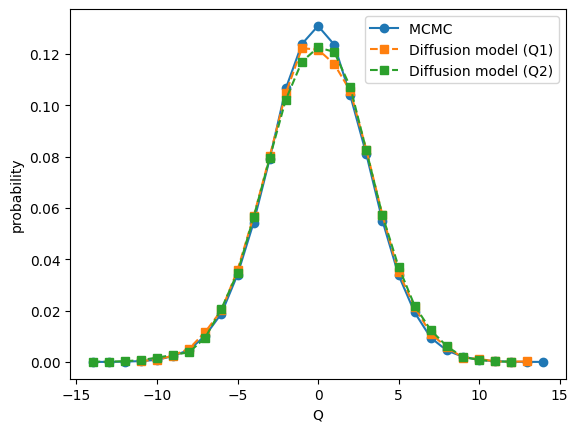

In [ ]:
vals1, nums1 = zip(*sorted(Q1_training.items()))
vals2, nums2 = zip(*sorted(Q1_model.items()))
vals3, nums3 = zip(*sorted(Q2_model.items()))

plt.figure()
plt.plot(vals1, nums1, "o-", label="MCMC ")
plt.plot(vals2, nums2, "s--", label="Diffusion model (Q1)")
plt.plot(vals3, nums3, "s--", label="Diffusion model (Q2)")
plt.xlabel("Q")
plt.ylabel("probability")
plt.legend()
plt.show()


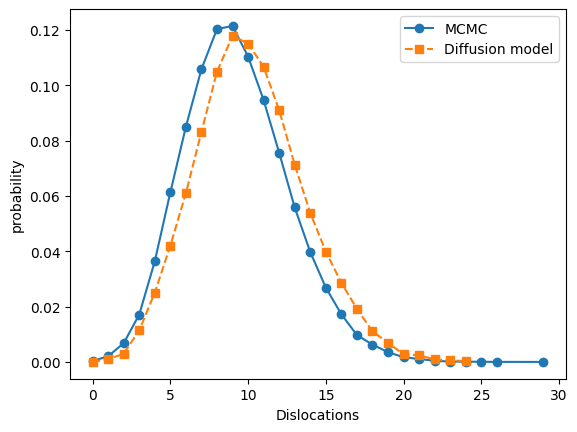

In [ ]:
vals1, nums1 = zip(*sorted(D_training.items()))
vals2, nums2 = zip(*sorted(D_model.items()))

plt.figure()
plt.plot(vals1, nums1, "o-", label="MCMC")
plt.plot(vals2, nums2, "s--", label="Diffusion model")
plt.xlabel("Dislocations")
plt.ylabel("probability")
plt.legend()
plt.show()


### Minor heat-bath clean-up

There were systematically too many dislocations produced by the bare model. The following test shows that a cheap 4 sweep clean-up considerably improves quality. For comparison, equilibration from a random distribution takes roughly 800 sweeps.


In [ ]:
# Systematically a bit too many dislocations. Let's try 4 heat bath sweep

cfgsHB = mcmc.heatBath(cfgsTop, beta, 4)

corrHB = mcmc.correlation(cfgsHB)
print(1, corrHB[1], corrTraining[1])
print(2, corrHB[2], corrTraining[2])
print(4, corrHB[4], corrTraining[4])
print(8, corrHB[8], corrTraining[8])

  0%|          | 0/4 [00:00<?, ?it/s]

1 tensor(0.6016, device='cuda:0') 0.6017
2 tensor(0.4335, device='cuda:0') 0.4339
4 tensor(0.2776, device='cuda:0') 0.2781
8 tensor(0.1472, device='cuda:0') 0.1469


In [ ]:
Q1, Q2, defects = mcmc.topCharge(cfgsTop)

Q1i = torch.round(Q1).to(torch.int64).cpu()
Q2i = torch.round(Q2).to(torch.int64).cpu()
Di = torch.round(defects).to(torch.int64).cpu()

Q1_counts = Counter(Q1i.tolist())
Q2_counts = Counter(Q2i.tolist())
D_counts = Counter(Di.tolist())

Q1_model = {q: count/len(Q1i) for q, count in Q1_counts.items()}
Q2_model = {q: count/len(Q2i) for q, count in Q2_counts.items()}
D_model = {d: count/len(Di) for d, count in D_counts.items()}

chi1_training = sum(q*q*p for q, p in Q1_training.items()) / 64**2
chi2_training = sum(q*q*p for q, p in Q2_training.items()) / 64**2
chi1_model = torch.mean(Q1**2).item() / 64**2
chi2_model = torch.mean(Q2**2).item() / 64**2

print("topological susceptibility")
print("training:", chi1_training, chi2_training)
print("model:   ", chi1_model, chi2_model)

print("\nmean dislocations")
print("training:", sum(d*p for d, p in D_training.items()))
print("model:   ", defects.mean().item())

topological susceptibility
training: 0.00232898193359375 0.0023440380859375
model:    0.0023713866248726845 0.002357983263209462

mean dislocations
training: 9.25971
model:    9.261317253112793


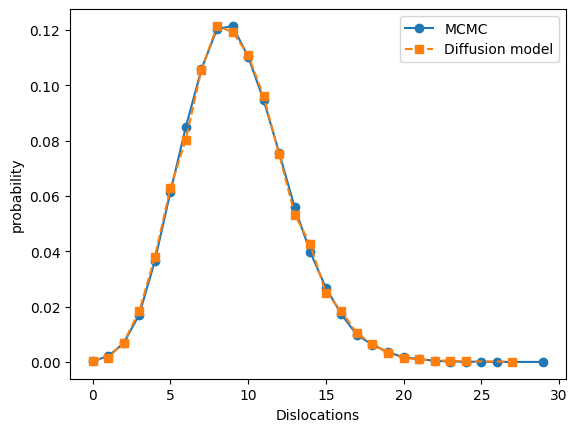

In [ ]:
vals1, nums1 = zip(*sorted(D_training.items()))
vals2, nums2 = zip(*sorted(D_model.items()))

plt.figure()
plt.plot(vals1, nums1, "o-", label="MCMC")
plt.plot(vals2, nums2, "s--", label="Diffusion model")
plt.xlabel("Dislocations")
plt.ylabel("probability")
plt.legend()
plt.show()